# PPO Portfolio Model Training

Train PPO model with log return reward and compare against baselines.

**Model:**
- PPO with `log_return` reward: log(V_t+1) - log(V_t)
- 100 features selected by importance from metadata
- Anti-overfitting hyperparameters

**Baseline Strategies:**
1. Equal Weight
2. Buy & Hold
3. Risk Parity
4. Momentum
5. Min Variance

**Key Features:**
- Walk-forward validation with 26-week embargo gap
- Early stopping to prevent overfitting
- All hyperparameters from `config.py`

## 1. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import config and RL system
from config import *
from rl_system import (
    load_data,
    PortfolioEnv2,  # Using holdings-based implementation
    PortfolioMonitor,
    TrainingLogger,
    create_walk_forward_folds,
    print_fold_summary,
    # Baseline strategies
    EqualWeight,
    BuyHold,
    RiskParity,
    Momentum,
    MinVariance,
    backtest_baseline
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Setup complete")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Using PortfolioEnv2 (holdings-based implementation)")

Setup complete
Timestamp: 2025-11-20 07:28:20
Using PortfolioEnv2 (holdings-based implementation)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. Configuration

In [2]:
# Print configuration
print("="*80)
print("TRAINING CONFIGURATION")
print("="*80)

print(f"\nData:")
print(f"  Path: {DATA_PATH}")
print(f"  Tickers: {len(TICKERS)} - {', '.join(TICKERS)}")
print(f"  Features: {len(FEATURE_COLS)} features")

print(f"\nEnvironment:")
print(f"  Reward: log_return (log(V_t+1) - log(V_t))")
print(f"  Rebalance: {REBALANCE_FREQUENCY} weeks")
print(f"  Transaction cost: {TRANSACTION_COST*10000:.0f} bps")
print(f"  Max weight: {MAX_WEIGHT_PER_ASSET:.0%}")

print(f"\nTraining (Anti-Overfitting):")
print(f"  Timesteps: {TOTAL_TIMESTEPS:,}")
print(f"  Early stop patience: {EARLY_STOP_PATIENCE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Network: {POLICY_KWARGS['net_arch']}")
print(f"  Entropy coef: {ENT_COEF}")
print(f"  Batch size: {BATCH_SIZE}")

print(f"\nValidation:")
print(f"  Folds: {N_FOLDS}")
print(f"  Embargo gap: 26 weeks")

print("="*80)

TRAINING CONFIGURATION

Data:
  Path: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed/train.parquet
  Tickers: 7 - NVDA, MU, AAPL, AMD, ASML, MSFT, GOOG
  Features: 100 features

Environment:
  Reward: log_return (log(V_t+1) - log(V_t))
  Rebalance: 4 weeks
  Transaction cost: 25 bps
  Max weight: 40%

Training (Anti-Overfitting):
  Timesteps: 100,000
  Early stop patience: 5
  Learning rate: 0.0001
  Network: [256, 256]
  Entropy coef: 0.01
  Batch size: 64

Validation:
  Folds: 3
  Embargo gap: 26 weeks


## 3. Load Data

In [3]:
# Load training data
train_data = load_data()

print(f"Loaded {len(train_data):,} samples")
print(f"Date range: {train_data[DATE_COL].min().date()} to {train_data[DATE_COL].max().date()}")
print(f"Tickers: {train_data['ticker'].nunique()}")
print(f"Features: {len(FEATURE_COLS)}")

Loaded 3,164 samples
Date range: 2015-01-01 to 2023-08-24
Tickers: 7
Features: 100


## 4. Create Walk-Forward Folds

In [4]:
# Create folds with 26-week embargo gap
folds = create_walk_forward_folds(
    train_data=train_data,
    n_folds=N_FOLDS,
    embargo_size=26,  # 26 weeks embargo to prevent leakage
    date_col=DATE_COL
)

print_fold_summary(folds)
print(f"\nCreated {len(folds)} walk-forward folds with embargo")


WALK-FORWARD VALIDATION FOLDS

Fold 0:
  Train: 2015-01-01 to 2016-09-15 (90 periods)
  Embargo gap: 26 periods
  Val:   2017-03-23 to 2019-01-03 (94 periods)
  Samples: Train=630, Val=658

Fold 1:
  Train: 2015-01-01 to 2019-01-03 (210 periods)
  Embargo gap: 26 periods
  Val:   2019-07-11 to 2021-04-22 (94 periods)
  Samples: Train=1470, Val=658

Fold 2:
  Train: 2015-01-01 to 2021-04-22 (330 periods)
  Embargo gap: 26 periods
  Val:   2021-10-28 to 2023-08-10 (94 periods)
  Samples: Train=2310, Val=658

Created 3 walk-forward folds with embargo


## 5. Train PPO Model

In [5]:
def train_ppo_fold(fold_idx, train_data, val_data):
    """Train PPO model on one fold with early stopping."""
    
    # Header
    print(f"\n{'='*80}")
    print(f"PPO - LOG_RETURN | FOLD {fold_idx + 1}/{N_FOLDS}")
    print(f"{'='*80}")
    
    # Data info
    train_periods = len(train_data[DATE_COL].unique())
    val_periods = len(val_data[DATE_COL].unique())
    train_start = train_data[DATE_COL].min().strftime('%Y-%m-%d')
    train_end = train_data[DATE_COL].max().strftime('%Y-%m-%d')
    val_start = val_data[DATE_COL].min().strftime('%Y-%m-%d')
    val_end = val_data[DATE_COL].max().strftime('%Y-%m-%d')
    
    print(f"\nData:")
    print(f"   Train: {train_start} to {train_end} ({train_periods} periods)")
    print(f"   Val:   {val_start} to {val_end} ({val_periods} periods)")
    print(f"   No data leakage")
    
    # Create environments using PortfolioEnv2 (holdings-based)
    def make_train_env():
        env = PortfolioEnv2(
            data=train_data.copy(),
            feature_cols=FEATURE_COLS,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            max_weight_per_asset=MAX_WEIGHT_PER_ASSET,
            reward_lookback=REWARD_LOOKBACK,
            initial_capital=INITIAL_CAPITAL,
            reward_type='log_return',
            seed=RANDOM_SEED + fold_idx,
            annualization_factor=ANNUALIZATION_FACTOR,
            risk_free_rate=RISK_FREE_RATE
        )
        return PortfolioMonitor(env)
    
    def make_val_env():
        env = PortfolioEnv2(
            data=val_data.copy(),
            feature_cols=FEATURE_COLS,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            max_weight_per_asset=MAX_WEIGHT_PER_ASSET,
            reward_lookback=REWARD_LOOKBACK,
            initial_capital=INITIAL_CAPITAL,
            reward_type='log_return',
            seed=RANDOM_SEED + fold_idx + 100,
            annualization_factor=ANNUALIZATION_FACTOR,
            risk_free_rate=RISK_FREE_RATE
        )
        return PortfolioMonitor(env)
    
    # Create vectorized environments
    train_env = DummyVecEnv([make_train_env])
    val_env = DummyVecEnv([make_val_env])
    
    # Wrap training env with VecNormalize for reward normalization
    # norm_obs=False because features are pre-normalized
    # norm_reward=True for PPO stability
    train_env = VecNormalize(train_env, norm_obs=False, norm_reward=True, clip_reward=10.0)
    
    # Output directory
    fold_dir = OUTPUT_DIR / 'ppo_log_return' / f'fold_{fold_idx}'
    fold_dir.mkdir(parents=True, exist_ok=True)
    
    # Training logger with early stopping
    training_logger = TrainingLogger(
        eval_env=val_env,
        eval_freq=EVAL_FREQ,
        fold_dir=fold_dir,
        patience=EARLY_STOP_PATIENCE,
        verbose=1
    )
    
    # Create model
    model = PPO(
        'MlpPolicy',
        train_env,
        learning_rate=LEARNING_RATE,
        n_steps=N_STEPS,
        batch_size=BATCH_SIZE,
        n_epochs=N_EPOCHS,
        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA,
        clip_range=CLIP_RANGE,
        ent_coef=ENT_COEF,
        vf_coef=VF_COEF,
        max_grad_norm=MAX_GRAD_NORM,
        policy_kwargs=POLICY_KWARGS,
        verbose=0,
        seed=RANDOM_SEED + fold_idx
    )
    
    # Train
    print(f"\nTraining for {TOTAL_TIMESTEPS:,} timesteps...\n")
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=training_logger,
        progress_bar=False
    )
    
    # Get best sharpe from logger
    best_sharpe = training_logger.get_best_sharpe()
    
    # Final validation run with best model
    best_model_path = fold_dir / 'best_model.zip'
    if not best_model_path.exists():
        raise FileNotFoundError(
            f"Best model not found at {best_model_path}. "
            f"Training may have failed or early stopped before saving."
        )
    
    best_model = PPO.load(str(best_model_path))
    obs = val_env.reset()
    done = False
    max_steps = 10000  # Safety limit to prevent infinite loops
    step_count = 0
    stats = None
    
    while not done and step_count < max_steps:
        action, _ = best_model.predict(obs, deterministic=True)
        # SB3 VecEnv returns 4 values (dones = terminated | truncated)
        obs, reward, dones, info = val_env.step(action)
        step_count += 1
        if dones[0]:
            done = True
            # Get stats from info (PortfolioMonitor stores it)
            if len(info) > 0 and 'portfolio_stats' in info[0]:
                stats = info[0]['portfolio_stats']
            else:
                # Fallback: try to get from environment
                val_env_unwrapped = val_env.envs[0]
                while hasattr(val_env_unwrapped, 'env'):
                    val_env_unwrapped = val_env_unwrapped.env
                stats = val_env_unwrapped.get_portfolio_stats()
    
    # Handle case where episode didn't complete
    if not done:
        print(f"Warning: Validation episode did not complete after {max_steps} steps")
        # Fallback: get stats from environment
        val_env_unwrapped = val_env.envs[0]
        while hasattr(val_env_unwrapped, 'env'):
            val_env_unwrapped = val_env_unwrapped.env
        stats = val_env_unwrapped.get_portfolio_stats()
    
    # Validate stats before use
    if not stats or len(stats) == 0:
        print("Warning: No portfolio stats available. Using defaults.")
        stats = {
            'sharpe_ratio': 0.0,
            'total_return': 0.0,
            'volatility': 0.0,
            'max_drawdown': 0.0,
            'portfolio_value': INITIAL_CAPITAL
        }
    
    print(f"\nFinal Results (Best Model):")
    print(f"  Sharpe Ratio:  {stats.get('sharpe_ratio', 0.0):.3f}")
    print(f"  Total Return:  {stats.get('total_return', 0.0):.2%}")
    print(f"  Max Drawdown:  {stats.get('max_drawdown', 0.0):.2%}")
    print(f"  Final Value:   ${stats.get('portfolio_value', 0.0):,.2f}")
    
    train_env.close()
    val_env.close()
    
    return {
        'fold': fold_idx,
        'sharpe_ratio': stats.get('sharpe_ratio', 0.0),
        'total_return': stats.get('total_return', 0.0),
        'volatility': stats.get('volatility', 0.0),
        'max_drawdown': stats.get('max_drawdown', 0.0),
        'portfolio_value': stats.get('portfolio_value', 0.0),
        'best_reward': best_sharpe,
        'model_path': str(best_model_path)
    }

print("Training function defined (using PortfolioEnv2)")

Training function defined (using PortfolioEnv2)


In [6]:
# Train PPO on all folds
ppo_results = []

for fold_idx, fold in enumerate(folds):
    result = train_ppo_fold(
        fold_idx=fold_idx,
        train_data=fold['train'],
        val_data=fold['val']
    )
    ppo_results.append(result)

# Summary
print(f"\n{'='*80}")
print("PPO TRAINING COMPLETE")
print(f"{'='*80}")

ppo_df = pd.DataFrame(ppo_results)
mean_sharpe = ppo_df['sharpe_ratio'].mean()
std_sharpe = ppo_df['sharpe_ratio'].std()

print(f"\nResults by fold:")
for _, row in ppo_df.iterrows():
    print(f"  Fold {int(row['fold'])}: Sharpe={row['sharpe_ratio']:.3f}, Return={row['total_return']:.2%}")

print(f"\nMean Sharpe: {mean_sharpe:.3f} +/- {std_sharpe:.3f}")
print(f"Mean Return: {ppo_df['total_return'].mean():.2%}")

# Save results
ppo_output_path = OUTPUT_DIR / 'ppo_log_return_results.csv'
ppo_df.to_csv(ppo_output_path, index=False)
print(f"\nSaved to: {ppo_output_path}")


PPO - LOG_RETURN | FOLD 1/3

Data:
   Train: 2015-01-01 to 2016-09-15 (90 periods)
   Val:   2017-03-23 to 2019-01-03 (94 periods)
   No data leakage

Training for 100,000 timesteps...

  Train Episode 20: Sharpe=1.026, Return=73.16%
  Train Episode 40: Sharpe=0.422, Return=34.16%

  Validation at step 5000: Sharpe=0.290, Return=27.91%, Drawdown=-42.43%
  -> New best model saved (Sharpe: 0.290)
  Train Episode 60: Sharpe=1.776, Return=153.31%
  Train Episode 80: Sharpe=1.334, Return=118.85%
  Train Episode 100: Sharpe=1.223, Return=112.10%

  Validation at step 10000: Sharpe=0.071, Return=12.38%, Drawdown=-43.63%
  -> No improvement for 1/5 evaluations
  Train Episode 120: Sharpe=1.703, Return=178.29%
  Train Episode 140: Sharpe=1.972, Return=183.61%
  Train Episode 160: Sharpe=2.283, Return=289.63%

  Validation at step 15000: Sharpe=-0.247, Return=-10.27%, Drawdown=-51.07%
  -> No improvement for 2/5 evaluations
  Train Episode 180: Sharpe=2.111, Return=252.20%
  Train Episode 200: 

## 6. Train Baseline Strategies

In [7]:
def train_baseline_fold(fold_idx, train_data, val_data, strategy_name):
    """Run baseline strategy on one fold."""
    
    # Get validation date range
    val_start = val_data[DATE_COL].min()
    val_end = val_data[DATE_COL].max()
    
    # Combine train + val for lookback calculations
    full_data = pd.concat([train_data, val_data], ignore_index=True)
    
    # Create strategy
    if strategy_name == 'equal_weight':
        strategy = EqualWeight(TICKERS, MAX_WEIGHT_PER_ASSET)
    elif strategy_name == 'buy_hold':
        strategy = BuyHold(TICKERS, MAX_WEIGHT_PER_ASSET)
    elif strategy_name == 'risk_parity':
        strategy = RiskParity(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, lookback=12)
    elif strategy_name == 'momentum':
        strategy = Momentum(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, lookback=12)
    elif strategy_name == 'min_variance':
        strategy = MinVariance(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, lookback=12)
    else:
        raise ValueError(f"Unknown strategy: {strategy_name}")
    
    # Backtest on validation period
    result = backtest_baseline(
        strategy=strategy,
        data=full_data,
        date_col=DATE_COL,
        tickers=TICKERS,
        rebalance_frequency=REBALANCE_FREQUENCY,
        transaction_cost=TRANSACTION_COST,
        initial_capital=INITIAL_CAPITAL,
        annualization_factor=ANNUALIZATION_FACTOR,
        risk_free_rate=RISK_FREE_RATE,
        start_date=val_start,
        end_date=val_end
    )
    
    stats = result.get('stats', {})
    
    # Validate stats before use
    if not stats or len(stats) == 0:
        print(f"Warning: No stats available for {strategy_name} fold {fold_idx}. Using defaults.")
        stats = {
            'sharpe_ratio': 0.0,
            'total_return': 0.0,
            'volatility': 0.0,
            'max_drawdown': 0.0,
            'portfolio_value': INITIAL_CAPITAL
        }
    
    return {
        'strategy': strategy_name,
        'fold': fold_idx,
        'sharpe_ratio': stats.get('sharpe_ratio', 0.0),
        'total_return': stats.get('total_return', 0.0),
        'volatility': stats.get('volatility', 0.0),
        'max_drawdown': stats.get('max_drawdown', 0.0),
        'portfolio_value': stats.get('portfolio_value', 0.0)
    }

print("Baseline training function defined")

Baseline training function defined


In [8]:
# Train all baselines
BASELINE_STRATEGIES = ['equal_weight', 'buy_hold', 'risk_parity', 'momentum', 'min_variance']
baseline_results = []

print(f"{'='*80}")
print("TRAINING BASELINE STRATEGIES")
print(f"{'='*80}\n")

for strategy_name in BASELINE_STRATEGIES:
    print(f"{strategy_name.upper()}:")
    
    for fold_idx, fold in enumerate(folds):
        result = train_baseline_fold(
            fold_idx=fold_idx,
            train_data=fold['train'],
            val_data=fold['val'],
            strategy_name=strategy_name
        )
        baseline_results.append(result)
        print(f"  Fold {fold_idx}: Sharpe={result.get('sharpe_ratio', 0.0):.3f}")
    print()

# Summary
baseline_df = pd.DataFrame(baseline_results)

print(f"{'='*80}")
print("BASELINE RESULTS SUMMARY")
print(f"{'='*80}\n")

for strategy in BASELINE_STRATEGIES:
    subset = baseline_df[baseline_df['strategy'] == strategy]
    print(f"{strategy.upper()}:")
    print(f"  Sharpe: {subset['sharpe_ratio'].mean():.3f} +/- {subset['sharpe_ratio'].std():.3f}")
    print(f"  Return: {subset['total_return'].mean():.2%}")

# Save results
baseline_output_path = OUTPUT_DIR / 'baseline_results.csv'
baseline_df.to_csv(baseline_output_path, index=False)
print(f"\nSaved to: {baseline_output_path}")

TRAINING BASELINE STRATEGIES

EQUAL_WEIGHT:
  Fold 0: Sharpe=0.417
  Fold 1: Sharpe=1.457
  Fold 2: Sharpe=-0.122

BUY_HOLD:
  Fold 0: Sharpe=0.287
  Fold 1: Sharpe=1.389
  Fold 2: Sharpe=-0.170

RISK_PARITY:
  Fold 0: Sharpe=0.508
  Fold 1: Sharpe=1.512
  Fold 2: Sharpe=-0.090

MOMENTUM:
  Fold 0: Sharpe=0.355
  Fold 1: Sharpe=1.476
  Fold 2: Sharpe=-0.167

MIN_VARIANCE:
  Fold 0: Sharpe=0.420
  Fold 1: Sharpe=1.456
  Fold 2: Sharpe=0.101

BASELINE RESULTS SUMMARY

EQUAL_WEIGHT:
  Sharpe: 0.584 +/- 0.803
  Return: 60.24%
BUY_HOLD:
  Sharpe: 0.502 +/- 0.801
  Return: 54.35%
RISK_PARITY:
  Sharpe: 0.644 +/- 0.810
  Return: 60.27%
MOMENTUM:
  Sharpe: 0.555 +/- 0.839
  Return: 62.45%
MIN_VARIANCE:
  Sharpe: 0.659 +/- 0.709
  Return: 62.64%

Saved to: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/baseline_results.csv


## 7. Compare All Models

In [9]:
# Calculate summary statistics
print(f"{'='*80}")
print("MODEL COMPARISON")
print(f"{'='*80}\n")

# PPO stats
ppo_sharpe = ppo_df['sharpe_ratio'].mean()
ppo_return = ppo_df['total_return'].mean()

print(f"PPO LOG_RETURN:")
print(f"  Sharpe: {ppo_sharpe:.3f} +/- {ppo_df['sharpe_ratio'].std():.3f}")
print(f"  Return: {ppo_return:.2%}")
print()

# Baseline stats and ranking
baseline_summary = baseline_df.groupby('strategy').agg({
    'sharpe_ratio': ['mean', 'std'],
    'total_return': 'mean'
}).round(4)
baseline_summary.columns = ['sharpe_mean', 'sharpe_std', 'return_mean']
baseline_summary = baseline_summary.sort_values('sharpe_mean', ascending=False)

print("BASELINES (ranked by Sharpe):")
for idx, (strategy, row) in enumerate(baseline_summary.iterrows(), 1):
    beat = "BEAT" if row['sharpe_mean'] > ppo_sharpe else ""
    print(f"  {idx}. {strategy}: {row['sharpe_mean']:.3f} +/- {row['sharpe_std']:.3f} {beat}")

# Best baseline
best_baseline = baseline_summary.index[0]
best_baseline_sharpe = baseline_summary.iloc[0]['sharpe_mean']

print(f"\nCOMPARISON:")
if ppo_sharpe > best_baseline_sharpe:
    print(f"  PPO beats best baseline ({best_baseline}) by {ppo_sharpe - best_baseline_sharpe:.3f}")
else:
    print(f"  Best baseline ({best_baseline}) beats PPO by {best_baseline_sharpe - ppo_sharpe:.3f}")

MODEL COMPARISON

PPO LOG_RETURN:
  Sharpe: 0.610 +/- 0.759
  Return: 73.73%

BASELINES (ranked by Sharpe):
  1. min_variance: 0.659 +/- 0.709 BEAT
  2. risk_parity: 0.644 +/- 0.810 BEAT
  3. equal_weight: 0.584 +/- 0.803 
  4. momentum: 0.555 +/- 0.839 
  5. buy_hold: 0.502 +/- 0.801 

COMPARISON:
  Best baseline (min_variance) beats PPO by 0.048


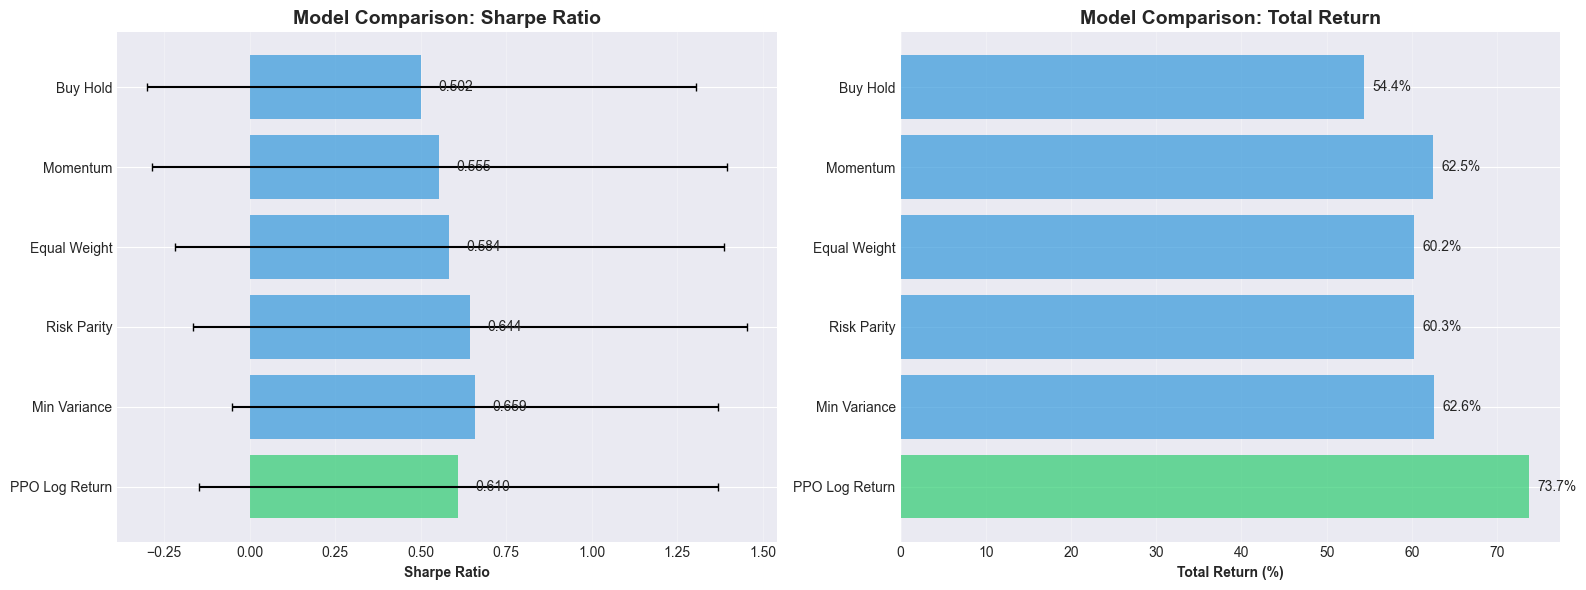


Saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/model_comparison.png


In [10]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sharpe comparison
ax1 = axes[0]

# Prepare data
models = ['PPO Log Return'] + [s.replace('_', ' ').title() for s in baseline_summary.index]
sharpes = [ppo_sharpe] + baseline_summary['sharpe_mean'].tolist()
stds = [ppo_df['sharpe_ratio'].std()] + baseline_summary['sharpe_std'].tolist()
colors = ['#2ecc71'] + ['#3498db'] * len(baseline_summary)

bars = ax1.barh(models, sharpes, color=colors, alpha=0.7, xerr=stds, capsize=3)
ax1.set_xlabel('Sharpe Ratio', fontweight='bold')
ax1.set_title('Model Comparison: Sharpe Ratio', fontweight='bold', fontsize=14)
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars, sharpes):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', fontsize=10)

# Plot 2: Return comparison
ax2 = axes[1]
returns = [ppo_return * 100] + (baseline_summary['return_mean'] * 100).tolist()
bars = ax2.barh(models, returns, color=colors, alpha=0.7)
ax2.set_xlabel('Total Return (%)', fontweight='bold')
ax2.set_title('Model Comparison: Total Return', fontweight='bold', fontsize=14)
ax2.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, val in zip(bars, returns):
    ax2.text(val + 1, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()

# Save plot
plot_path = OUTPUT_DIR / 'model_comparison.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved: {plot_path}")

## 8. Summary

In [11]:
print(f"{'='*80}")
print("TRAINING COMPLETE")
print(f"{'='*80}\n")

print(f"PPO Model:")
print(f"  Mean Sharpe: {ppo_sharpe:.3f} +/- {ppo_df['sharpe_ratio'].std():.3f}")
print(f"  Mean Return: {ppo_return:.2%}")
print(f"  Model path: {OUTPUT_DIR / 'ppo_log_return'}")

print(f"\nBest Baseline: {best_baseline}")
print(f"  Sharpe: {best_baseline_sharpe:.3f}")

print(f"\nOutput files:")
print(f"  - ppo_log_return_results.csv")
print(f"  - baseline_results.csv")
print(f"  - model_comparison.png")
print(f"  - ppo_log_return/fold_*/best_model.zip")

print(f"\nNext steps:")
print(f"  1. Run 03_backtests_all_models.ipynb for test set evaluation")
print(f"  2. Run 04_overfitting_investigation.ipynb for overfitting analysis")

TRAINING COMPLETE

PPO Model:
  Mean Sharpe: 0.610 +/- 0.759
  Mean Return: 73.73%
  Model path: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/ppo_log_return

Best Baseline: min_variance
  Sharpe: 0.659

Output files:
  - ppo_log_return_results.csv
  - baseline_results.csv
  - model_comparison.png
  - ppo_log_return/fold_*/best_model.zip

Next steps:
  1. Run 03_backtests_all_models.ipynb for test set evaluation
  2. Run 04_overfitting_investigation.ipynb for overfitting analysis


## Notes

**Model Configuration:**
- PPO with log_return reward: log(V_t+1) - log(V_t)
- 100 features selected by importance from metadata
- Anti-overfitting hyperparameters (reduced timesteps, smaller network, higher entropy)

**Training Features:**
- Walk-forward validation with 26-week embargo gap
- Early stopping to prevent overfitting
- Best model saved per fold

**Output:**
- `models/ppo_log_return/fold_*/best_model.zip`
- `models/ppo_log_return_results.csv`
- `models/baseline_results.csv`
- `models/model_comparison.png`